# 01, Data Coverage

Per-country data quality audit. Answers: **which countries do we trust, and where are the landmines?**

Inputs:
- `data/parquet/clean/equity.parquet`, 30 countries daily close + OHLV
- `data/parquet/clean/fx.parquet`, 31 countries daily vs-USD
- `data/parquet/clean/btc_1min.parquet`, 1-min Binance
- `data/parquet/gold/panel.parquet`, merged country × date panel

Stack: polars + duckdb + matplotlib/seaborn.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
con = duckdb.connect()
SILVER = '../data/parquet/clean'
GOLD = '../data/parquet/gold'

In [2]:
# Show all columns (use -1 to disable the limit)
pl.Config.set_tbl_cols(-1)

# Show up to 200 rows
pl.Config.set_tbl_rows(200)

# Show full string content in cells (increase this number if text gets cut off)
pl.Config.set_fmt_str_lengths(1000)

polars.config.Config

## 1. Panel shape

Sanity: 31 countries × ~1,825 trading days ≈ 56,500 rows expected.

In [3]:
panel = pl.read_parquet(f'{GOLD}/panel.parquet')
print(f'rows: {panel.height:,}, countries: {panel["country_id"].n_unique()}')
print(f'date span: {panel["date"].min()} → {panel["date"].max()}')
print('\nnull-counts:')
print(panel.null_count().transpose(include_header=True, column_names=['nulls']))

rows: 166,525, countries: 89
date span: 2019-01-01 00:00:00 → 2025-12-31 00:00:00

null-counts:
shape: (13, 2)
┌────────────┬───────┐
│ column     ┆ nulls │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ date       ┆ 0     │
│ country_id ┆ 0     │
│ equity_ret ┆ 12880 │
│ fx_ret     ┆ 10759 │
│ btc_rv     ┆ 0     │
│ eth_rv     ┆ 0     │
│ chinn_ito  ┆ 0     │
│ crypto_ban ┆ 0     │
│ err_float  ┆ 0     │
│ vix        ┆ 10229 │
│ dxy        ┆ 11437 │
│ sp500      ┆ 10229 │
│ oil        ┆ 9966  │
└────────────┴───────┘


## 2. Per-country equity & FX coverage

For each country, how many days do we actually have a close price? Expected full-history = 2,557 calendar days but trading calendars vary; ~1,750 is a normal developed-market count.

In [4]:
cov = con.execute(f"""
WITH eq AS (
  SELECT country_id, COUNT(*) AS eq_days,
         MIN(date) AS eq_first, MAX(date) AS eq_last
  FROM '{SILVER}/equity.parquet'
  GROUP BY country_id
),
fx AS (
  SELECT country_id, COUNT(*) AS fx_days,
         MIN(date) AS fx_first, MAX(date) AS fx_last
  FROM '{SILVER}/fx.parquet'
  GROUP BY country_id
)
SELECT COALESCE(eq.country_id, fx.country_id) AS country_id,
       eq_days, fx_days,
       eq_first, eq_last, fx_first, fx_last
FROM eq FULL OUTER JOIN fx USING (country_id)
ORDER BY country_id
""").pl()
cov

country_id,eq_days,fx_days,eq_first,eq_last,fx_first,fx_last
str,i64,i64,datetime[ns],datetime[ns],datetime[ns],datetime[ns]
"""ARE""",1401,1820,2019-01-02 00:00:00,2025-12-30 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00
"""ARG""",1704,1821,2019-01-02 00:00:00,2025-12-30 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00
"""AUS""",1770,1821,2019-01-02 00:00:00,2025-12-30 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00
"""AUT""",1768,1821,2019-01-02 00:00:00,2025-12-30 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00
"""BEL""",1792,1821,2019-01-02 00:00:00,2025-12-30 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00
"""BGD""",1528,1821,2019-01-01 00:00:00,2025-12-30 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00
"""BGR""",1730,1820,2019-01-01 00:00:00,2025-12-22 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00
"""BHR""",1722,1821,2019-01-02 00:00:00,2025-12-31 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00
"""BIH""",1756,1821,2019-01-03 00:00:00,2025-12-31 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00


In [5]:
# Red-flag countries: <50% of median coverage
median_eq = cov['eq_days'].median()
median_fx = cov['fx_days'].median()
flagged = cov.filter(
    (pl.col('eq_days') < 0.5 * median_eq) | (pl.col('fx_days') < 0.5 * median_fx)
)
print(f'median eq_days = {median_eq}, median fx_days = {median_fx}')
print('\nred-flagged countries:')
flagged

median eq_days = 1739.0, median fx_days = 1821.0

red-flagged countries:


country_id,eq_days,fx_days,eq_first,eq_last,fx_first,fx_last
str,i64,i64,datetime[ns],datetime[ns],datetime[ns],datetime[ns]


## 3. Coverage heatmap, country × month

Which country-months are under-observed? A clean panel shows a uniform grid; gaps pop out visually.

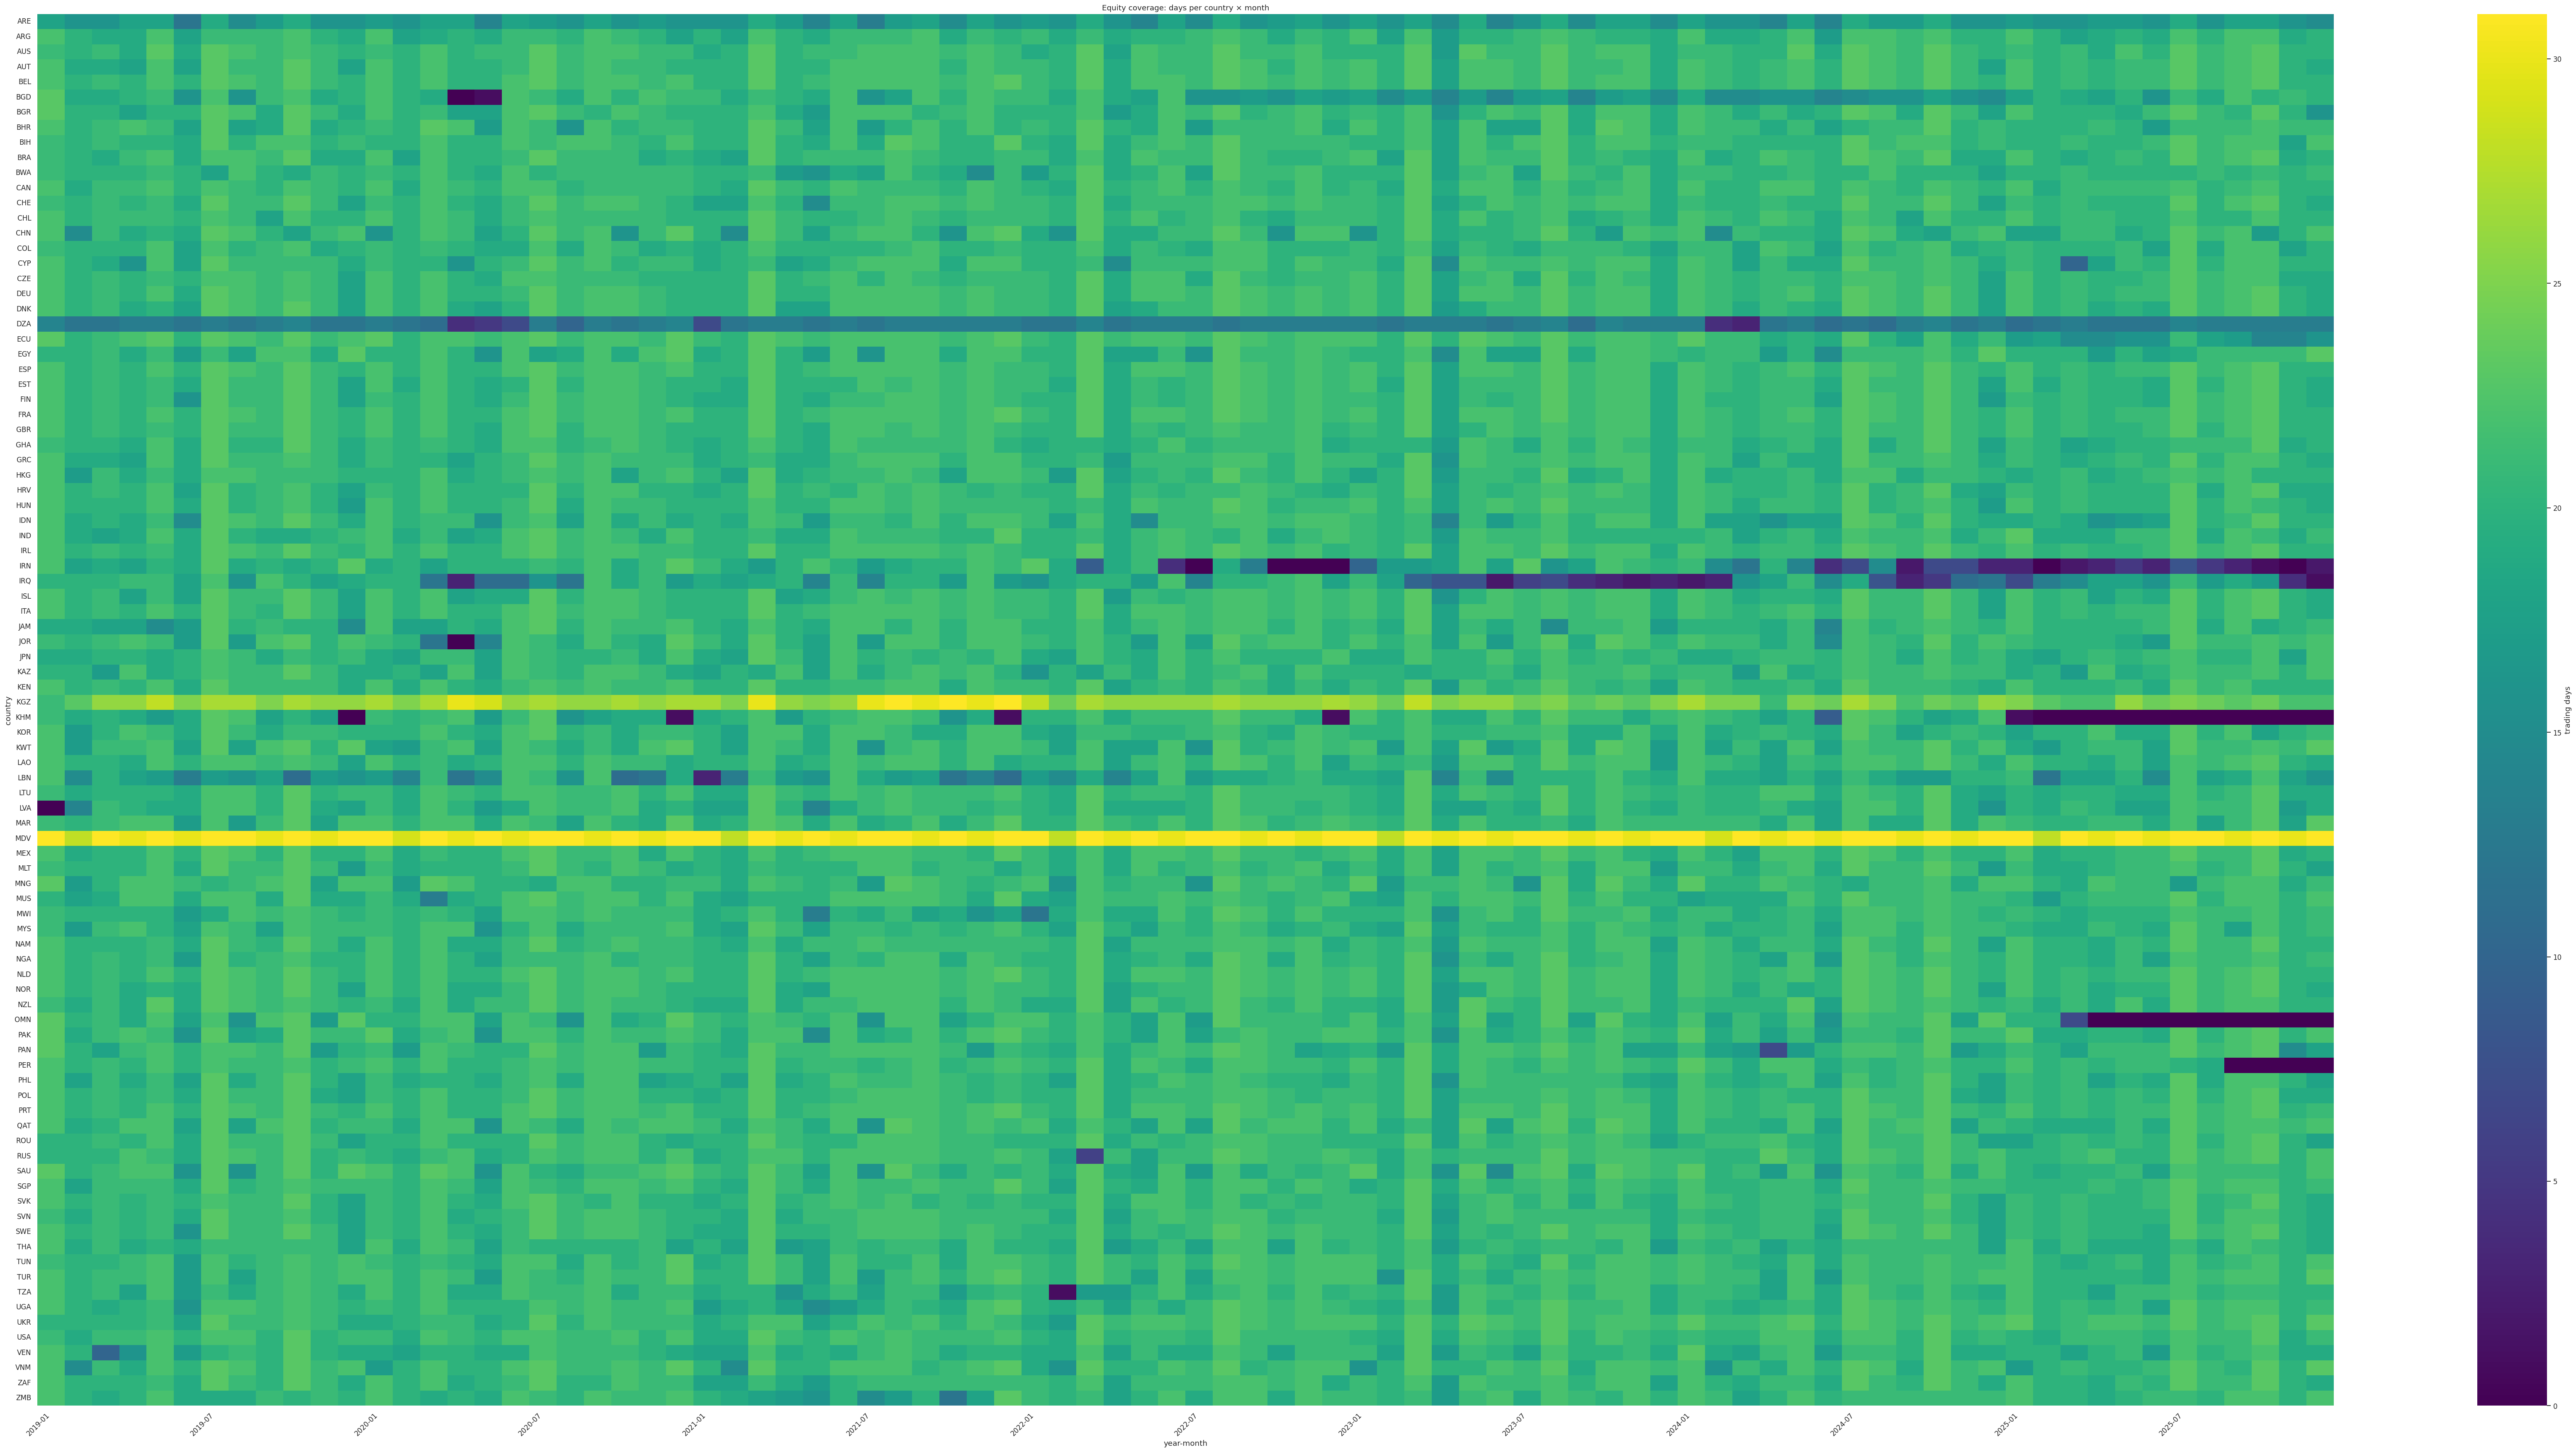

In [6]:
eq_cov = con.execute(f"""
SELECT country_id,
       strftime(date, '%Y-%m') AS yearmonth,
       COUNT(*) AS n_days
FROM '{SILVER}/equity.parquet'
GROUP BY 1, 2
ORDER BY 1, 2
""").df()
pivot = eq_cov.pivot(index='country_id', columns='yearmonth', values='n_days').fillna(0)
fig, ax = plt.subplots(figsize=(64, 32))
sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': 'trading days'}, ax=ax)
ax.set_title('Equity coverage: days per country × month')
ax.set_xlabel('year-month'); ax.set_ylabel('country')
# Show every 6th month on x-axis
xticks = ax.get_xticks()
xlabels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks(xticks[::6])
ax.set_xticklabels(xlabels[::6], rotation=45, ha='right')
plt.tight_layout()
plt.show()

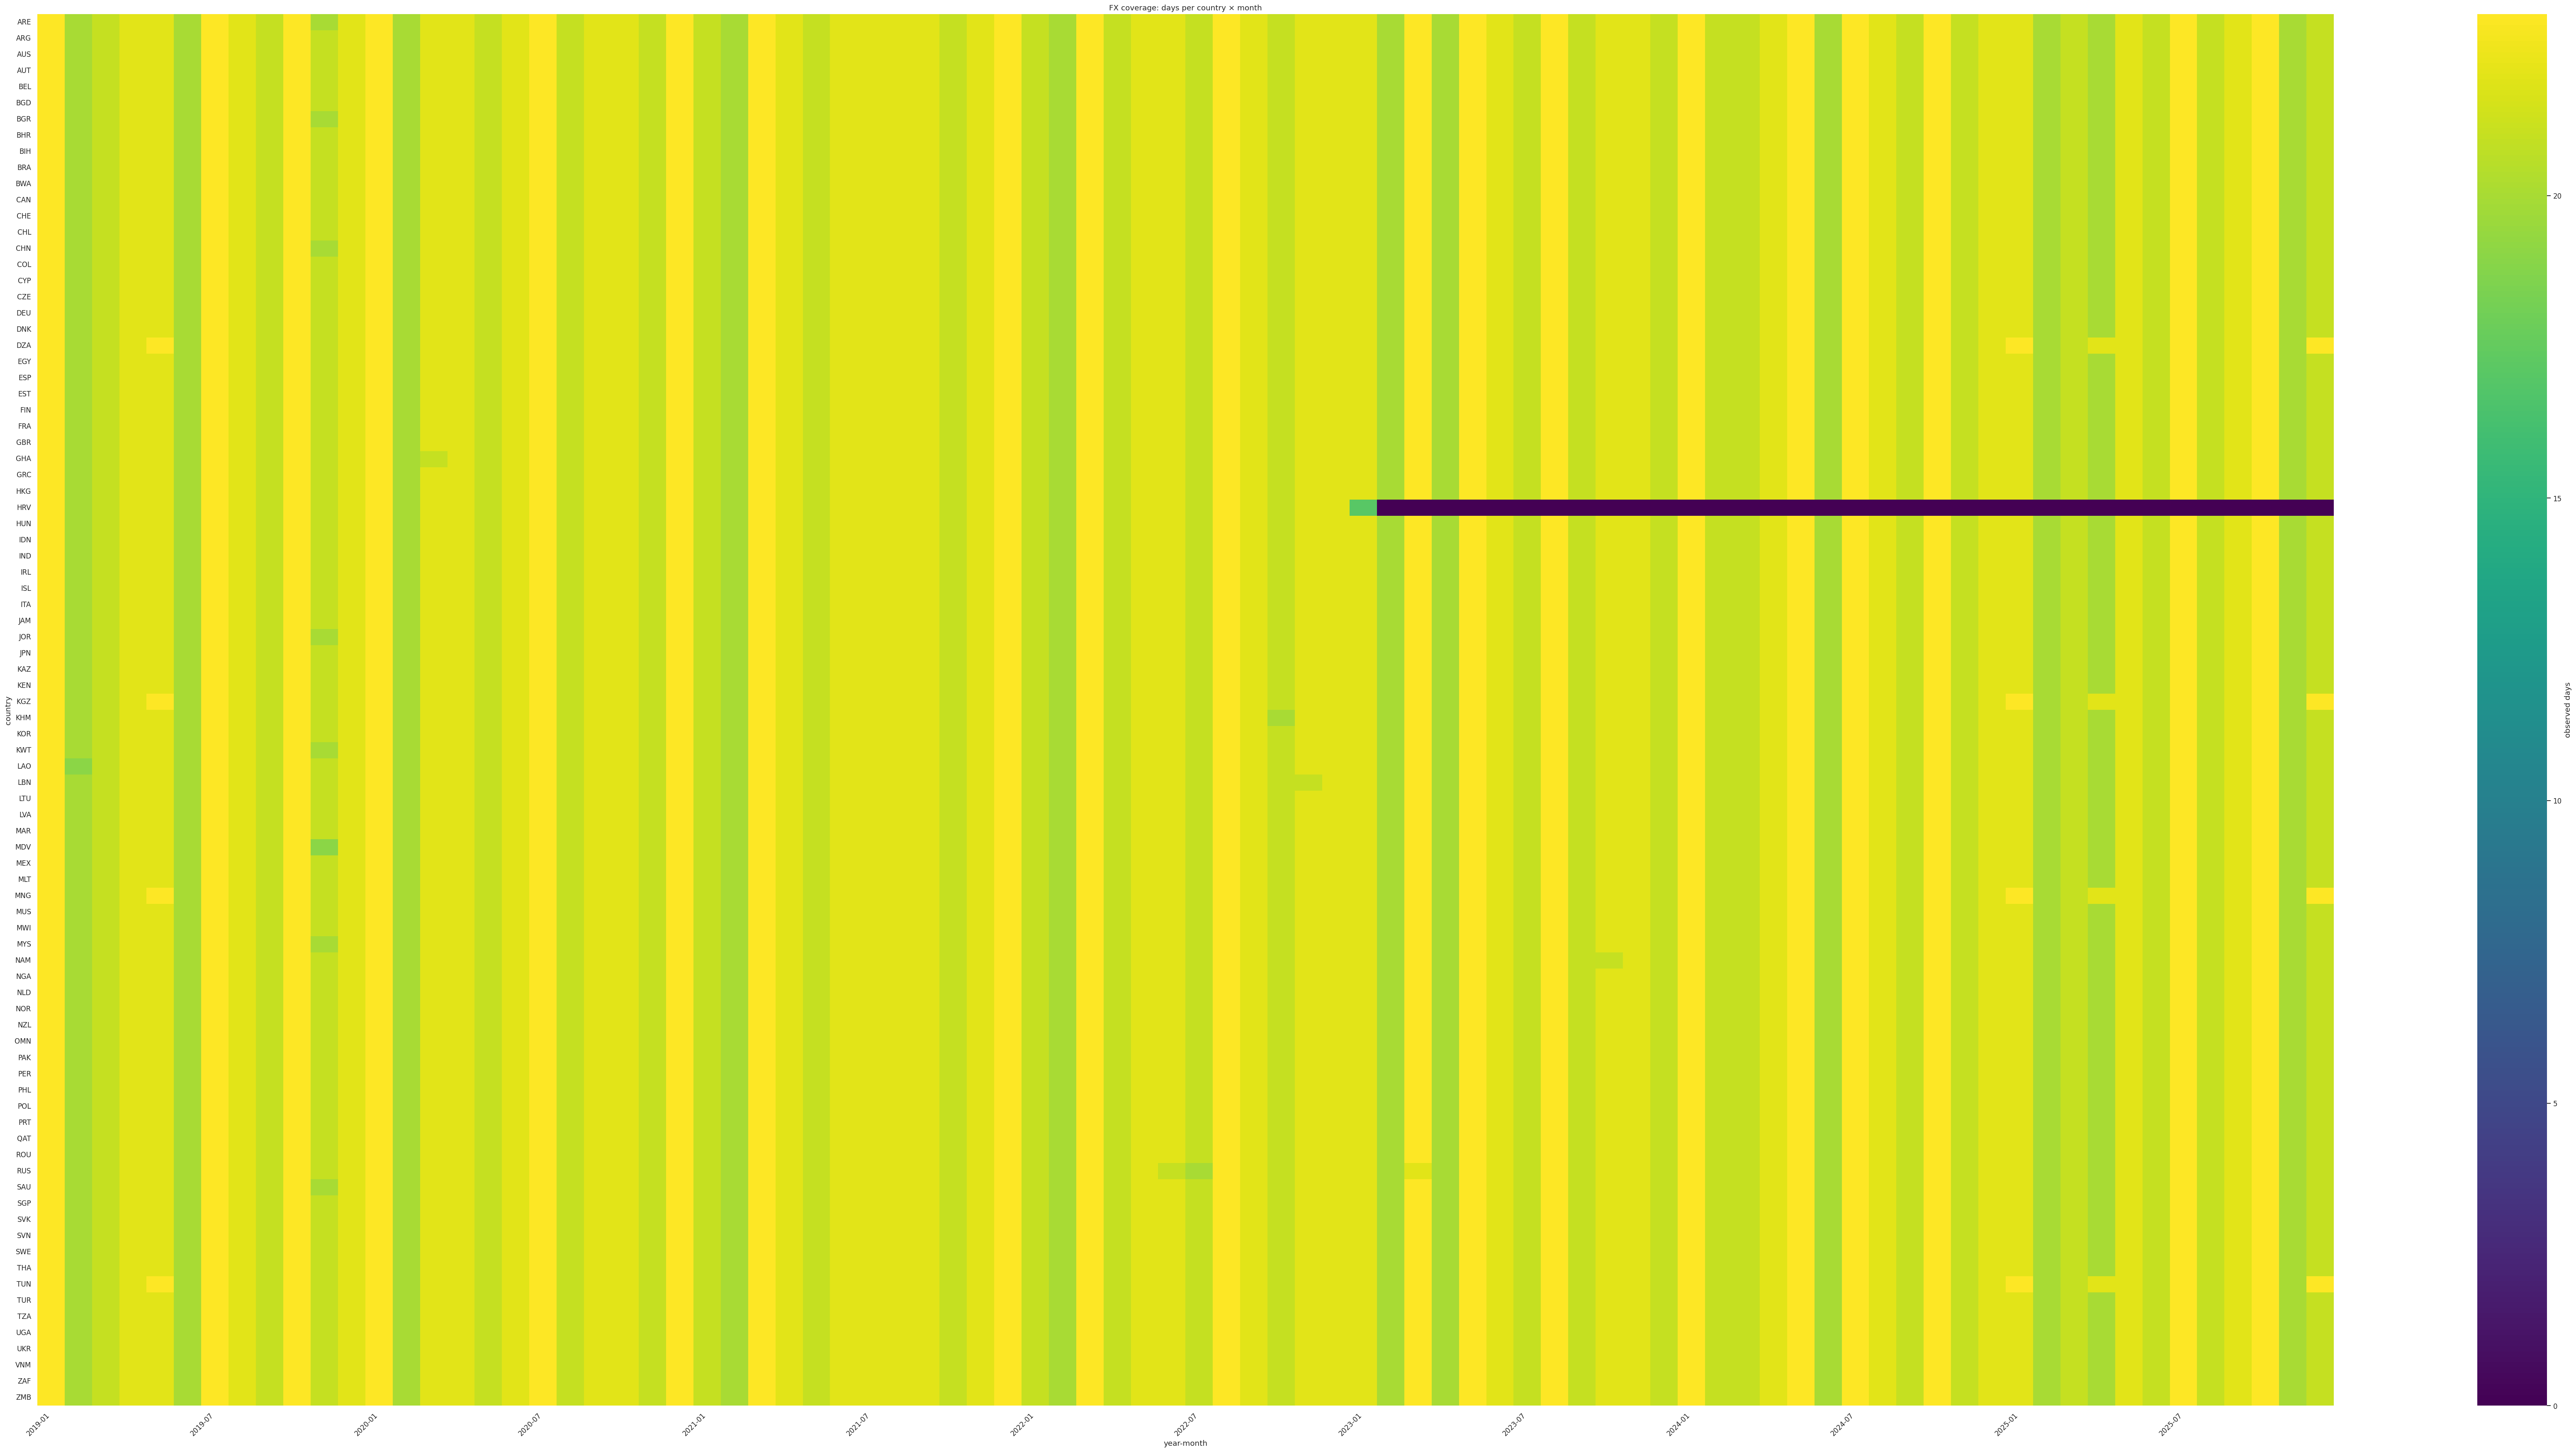

In [7]:
fx_cov = con.execute(f"""
SELECT country_id,
       strftime(date, '%Y-%m') AS yearmonth,
       COUNT(*) AS n_days
FROM '{SILVER}/fx.parquet'
GROUP BY 1, 2
ORDER BY 1, 2
""").df()
pivot_fx = fx_cov.pivot(index='country_id', columns='yearmonth', values='n_days').fillna(0)
fig, ax = plt.subplots(figsize=(64, 32))
sns.heatmap(pivot_fx, cmap='viridis', cbar_kws={'label': 'observed days'}, ax=ax)
ax.set_title('FX coverage: days per country × month')
ax.set_xlabel('year-month'); ax.set_ylabel('country')
xticks = ax.get_xticks()
xlabels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks(xticks[::6])
ax.set_xticklabels(xlabels[::6], rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Crypto 1-min gaps

Binance had 22 exchange-wide outages across 2019–2025 (identical for BTC and ETH, same exchange). We know 21 distinct UTC-days are affected; let's see which days lost most minutes.

In [8]:
gap_days = con.execute(f"""
WITH per_day AS (
  SELECT date_trunc('day', timestamp_utc) AS day,
         COUNT(*) AS n_min
  FROM '{SILVER}/btc_1min.parquet'
  GROUP BY 1
)
SELECT day, n_min, 1440 - n_min AS missing_min
FROM per_day
WHERE n_min < 1440
ORDER BY n_min
""").pl()
print(f'{gap_days.height} partial days out of 2557 ({gap_days.height / 2557:.2%})')
gap_days

21 partial days out of 2557 (0.82%)


day,n_min,missing_min
"datetime[μs, UTC]",i64,i64
2019-05-15 00:00:00 UTC,840,600
2019-08-15 00:00:00 UTC,960,480
2019-03-12 00:00:00 UTC,1080,360
2020-02-19 00:00:00 UTC,1086,354
2021-04-25 00:00:00 UTC,1156,284
2021-08-13 00:00:00 UTC,1170,270
2020-12-21 00:00:00 UTC,1188,252
2020-06-28 00:00:00 UTC,1230,210
2021-04-20 00:00:00 UTC,1290,150


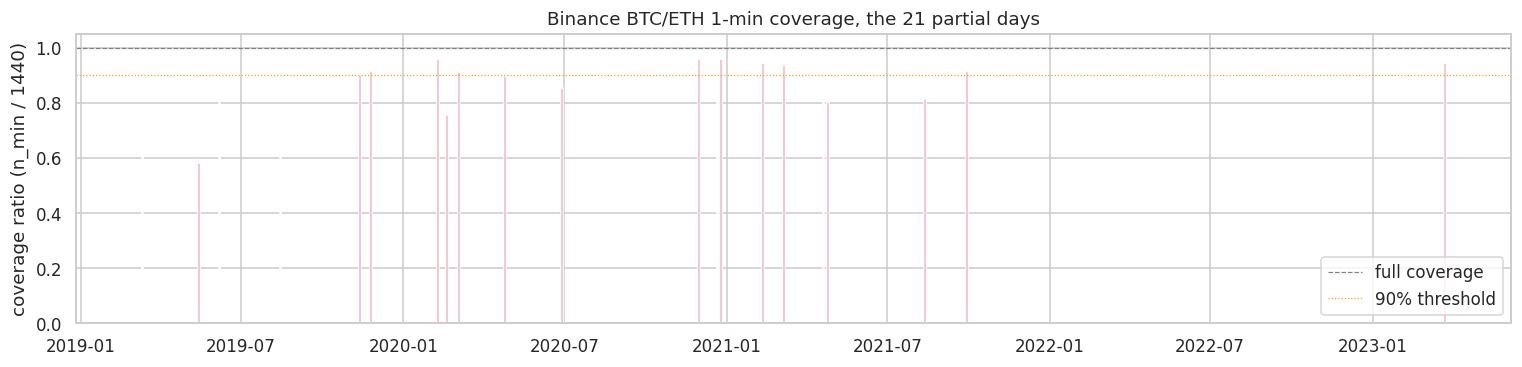

In [9]:
# Visual: coverage ratio per day
fig, ax = plt.subplots(figsize=(14, 3.5))
pd_days = gap_days.to_pandas()
ax.bar(pd_days['day'], pd_days['n_min'] / 1440, color='crimson', width=2.0)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='full coverage')
ax.axhline(0.9, color='orange', linestyle=':', linewidth=0.8, label='90% threshold')
ax.set_ylabel('coverage ratio (n_min / 1440)')
ax.set_title(f'Binance BTC/ETH 1-min coverage, the {gap_days.height} partial days')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## 5. OHLC vs close-only

How much of equity data is genuine OHLC (Garman-Klass usable) vs close-replicated-to-OHLC (common from Investing.com for frontier markets)?

A row where `high == low == open == close` is almost certainly close-only.

In [10]:
ohlc_quality = con.execute(f"""
SELECT country_id,
       source,
       COUNT(*) AS n_rows,
       SUM(CASE WHEN high IS NOT NULL AND low IS NOT NULL
                 AND high > low THEN 1 ELSE 0 END) AS n_real_hl,
       AVG(CASE WHEN high IS NOT NULL AND low IS NOT NULL
                 AND high > low THEN 1.0 ELSE 0.0 END) AS pct_real_hl
FROM '{SILVER}/equity.parquet'
GROUP BY 1, 2
ORDER BY pct_real_hl
""").pl()
ohlc_quality

country_id,source,n_rows,n_real_hl,pct_real_hl
str,str,i64,"decimal[38,0]",f64
"""MLT""","""investing""",1727,0,0.0
"""UGA""","""investing""",1723,0,0.0
"""MWI""","""investing""",1701,0,0.0
"""UKR""","""investing""",1781,0,0.0
"""MNG""","""investing""",1735,0,0.0
"""DZA""","""investing""",1015,0,0.0
"""ZMB""","""investing""",1697,0,0.0
"""KGZ""","""investing""",2162,0,0.0
"""BIH""","""investing""",1756,0,0.0


## 6. Volume availability

Realized volatility doesn't need volume, but volume-weighted sanity checks do. Which countries have usable volume at all?

**Interpretation:** countries with low `pct_real_hl` only have a close series. They must use simple squared returns for volatility estimation, no Parkinson or Garman-Klass estimator.

In [11]:
vol = con.execute(f"""
SELECT country_id, source,
       COUNT(*) AS n_rows,
       SUM(CASE WHEN volume IS NOT NULL AND volume > 0 THEN 1 ELSE 0 END) AS n_vol,
       AVG(CASE WHEN volume IS NOT NULL AND volume > 0 THEN 1.0 ELSE 0.0 END) AS pct_vol
FROM '{SILVER}/equity.parquet'
GROUP BY 1, 2
ORDER BY pct_vol DESC
""").pl()
vol

country_id,source,n_rows,n_vol,pct_vol
str,str,i64,"decimal[38,0]",f64
"""CHN""","""yahoo""",1696,1696,1.0
"""BHR""","""investing""",1722,1722,1.0
"""CHE""","""yahoo""",1747,1747,1.0
"""SAU""","""yahoo""",1727,1727,1.0
"""ARE""","""yahoo""",1401,1401,1.0
"""VNM""","""investing""",1749,1749,1.0
"""HUN""","""investing""",1747,1747,1.0
"""NOR""","""investing""",13,13,1.0
"""HKG""","""yahoo""",1721,1721,1.0


## 7. Summary table: KAOPEN tier × data quality

Join country quality back to the KAOPEN tier for a plan-aligned view.

In [12]:
import sys, yaml
sys.path.insert(0, '..')  # repo root, for src.features.kaopen_tier
from src.features.kaopen_tier import tier

with open('../config/countries.yaml') as f:
    cfg = yaml.safe_load(f)
configured = [c['id'] for c in cfg['countries']
              if c.get('equity', {}).get('source') or c.get('fx', {}).get('source')]

# KAOPEN now sourced from the canonical parquet (iso3 == country id, year 2023)
kaopen = (pl.read_parquet('../data/parquet/kaopen.parquet')
            .filter(pl.col('year') == 2023)
            .select(country_id='iso3', kaopen_2023='ka_open_normalized'))
tier_df = (kaopen.filter(pl.col('country_id').is_in(configured))
                 .with_columns(kaopen_tier=pl.col('kaopen_2023')
                               .map_elements(tier, return_dtype=pl.Utf8)))
summary = cov.join(tier_df, on='country_id', how='left').sort(['kaopen_tier', 'country_id'])
summary

country_id,eq_days,fx_days,eq_first,eq_last,fx_first,fx_last,kaopen_2023,kaopen_tier
str,i64,i64,datetime[ns],datetime[ns],datetime[ns],datetime[ns],f64,str
"""IRN""",1232,null,2019-01-01 00:00:00,2025-12-30 00:00:00,null,null,null,null
"""IRQ""",1262,null,2019-01-02 00:00:00,2025-12-23 00:00:00,null,null,null,null
"""VEN""",1670,null,2019-01-02 00:00:00,2025-12-30 00:00:00,null,null,null,null
"""BGR""",1730,1820,2019-01-01 00:00:00,2025-12-22 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00,0.446005,"""intermediate"""
"""COL""",1709,1821,2019-01-02 00:00:00,2025-12-30 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00,0.418133,"""intermediate"""
"""EGY""",1699,1821,2019-01-02 00:00:00,2025-12-31 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00,0.418133,"""intermediate"""
"""IDN""",1692,1821,2019-01-02 00:00:00,2025-12-30 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00,0.418133,"""intermediate"""
"""JAM""",1699,1821,2019-01-02 00:00:00,2025-12-31 00:00:00,2019-01-01 00:00:00,2025-12-30 00:00:00,0.418133,"""intermediate"""
"""KGZ""",2162,1827,2019-01-08 00:00:00,2025-12-27 00:00:00,2019-01-01 00:00:00,2025-12-31 00:00:00,0.539274,"""intermediate"""


## Takeaways

_Fill in as you review the outputs above:_

- **CHL** (Chile, Yahoo IPSA): fewest rows by far, Yahoo coverage broken, decision needed
- **HUN**: 651 rows, BUX also appears partial
- **Peru**: ends Aug 2025 per plan v4, visible in the heatmap
- **Frontier Investing equity**: most have OHLC identical (no real H/L), use close-only RV
- Volume is null for most non-Yahoo equities, not blocking for our analysis